# Imports and data

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Constants and Data
p_gL = np.array([0.0, 12.0, 39.0, 55.0])
mu_exp = np.array([0.9, 0.68, 0.52, 0.13])
pH = 6.3
pKa = 3.88
M_w = 90.08 #g/mol
mu_P0 = max(mu_exp)

# Part A

The Henderson-Hasselbalch equation relates the $pH$ of a weak acid solution to its $pK_a$:

$$pH = pK_a + \log_{10} \left( \frac{[Lac^-]}{[P]} \right)$$

and using the mass balance :

$$[Total] = [P] + [Lac^-]$$

we get :

$$[P] = \frac{[Total]}{1 + 10^{(pH - pK_a)}}$$

C:\Users\colin\AppData\Local\Temp\ipykernel_23016\2088567852.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


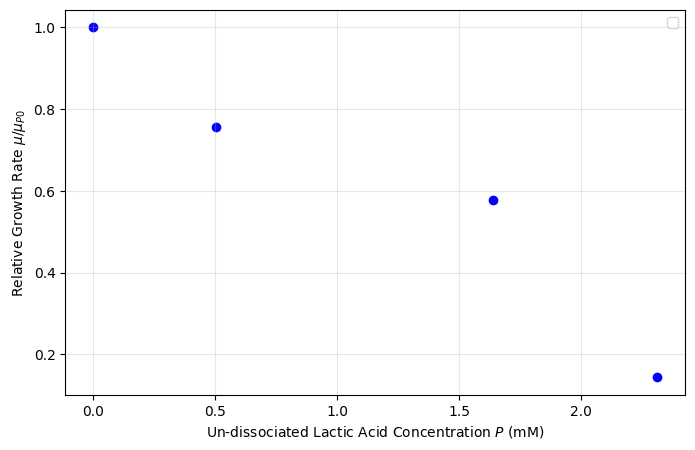

In [13]:
# Convert total mass concentration (g/L) to total molar concentration (mM)
total_mM = (p_gL / M_w) * 1000

P_mM = total_mM / (1 + 10**(pH - pKa))
mu_relative = mu_exp / mu_P0

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(P_mM, mu_relative, marker="o", color="blue")
plt.xlabel(r"Un-dissociated Lactic Acid Concentration $P$ (mM)")
plt.ylabel(r"Relative Growth Rate $\mu / \mu_{P0}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Part B

We here use:

$$\mu=\mu_{max}\frac{S}{K_M+S}\frac{1}{1+\frac{P}{K_I}}\simeq\mu_{max}\frac{1}{1+\frac{P}{K_I}}$$

and the fact that the system is under **substrate saturation** ($S \gg K_M$), which simplifies the Monod term $\frac{S}{K_M+S}$ to approximately 1. Under these conditions:

$$\mu\simeq\mu_{max}\frac{1}{1+\frac{P}{K_I}}$$

This can be rearranged as follows:

$$\frac{\mu_{max}}{\mu}-1=\left(\frac{1}{K_I}\right)P$$

We will fit both a version with a free intercept and another one with a forced intercept to 0 as predicted by the model.

Estimated Inhibition Constant K_I: 0.45649531875163263 mM


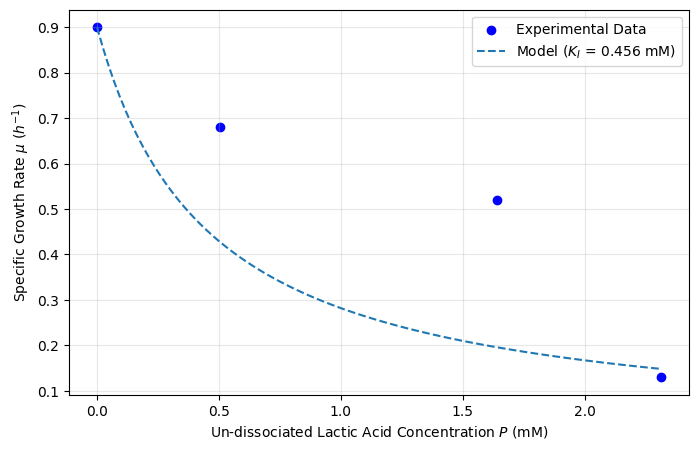

In [14]:
# Define x and y for the regression
x_b = P_mM
y_b = (mu_P0 / mu_exp) - 1

# Linear fit (y = mx + b)
coeffs_b = np.polyfit(x_b, y_b, 1)
slope_b = coeffs_b[0]
intercept_b = coeffs_b[1]

# Calculate K_I
K_I = 1 / slope_b
print(f"Estimated Inhibition Constant K_I: {K_I} mM")

# Plot the linear fit
P_line = np.linspace(0, max(P_mM), 100)
mu_model_KI = mu_P0 / (1 + P_line / K_I)


plt.figure(figsize=(8, 5))
plt.scatter(P_mM, mu_exp, color="blue", label="Experimental Data")
plt.plot(P_line, mu_model_KI, "--", label=f"Model ($K_I$ = {K_I:.3f} mM)")

plt.xlabel(r"Un-dissociated Lactic Acid Concentration $P$ (mM)")
plt.ylabel(r"Specific Growth Rate $\mu$ ($h^{-1}$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [26]:
print(f"slope = {slope_b:.4f}, intercept = {intercept_b:.4f} (model predicts 0)")

slope = 2.1906, intercept = -0.6965 (model predicts 0)


We see that the intercept is not 0 as predicted by the model. We can perform a regression while forcing the intercept :

## B additionnal : fit with contrained intercept

Free fit: slope = 2.1906, intercept = -0.6965 (model predicts 0)
Forced fit: slope = 1.8162, intercept = 0
K_I (free intercept): 0.4565 mM
K_I (forced intercept): 0.5506 mM

SSE in linearized space (free): 7.59315
SSE in linearized space (forced): 8.37131
SSE in mu space (free): 0.16908
SSE in mu space (forced): 0.13241


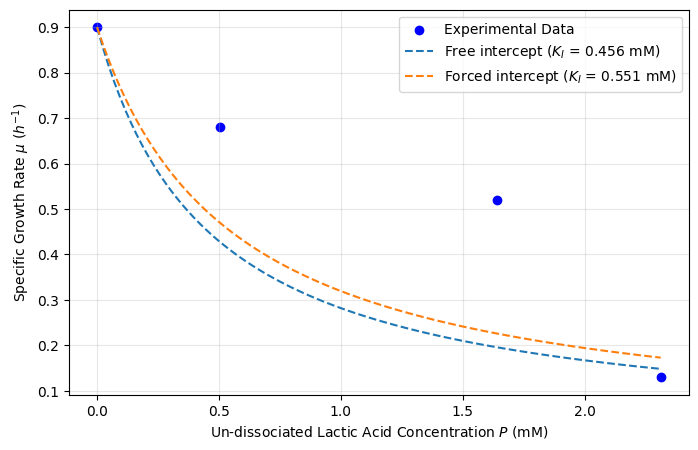

In [30]:
# Force intercept = 0: y = a*x  =>  a = sum(x*y)/sum(x^2)
slope_b_zero = np.sum(x_b * y_b) / np.sum(x_b**2)
K_I_zero = 1 / slope_b_zero
print(f"Free fit: slope = {slope_b:.4f}, intercept = {intercept_b:.4f} (model predicts 0)")
print(f"Forced fit: slope = {slope_b_zero:.4f}, intercept = 0")
print(f"K_I (free intercept): {K_I:.4f} mM")
print(f"K_I (forced intercept): {K_I_zero:.4f} mM")

# SSE in the linearized space (on y_b = mu_max/mu - 1)
y_pred_free = slope_b * x_b + intercept_b
y_pred_forced = slope_b_zero * x_b
sse_lin_free = np.sum((y_b - y_pred_free)**2)
sse_lin_forced = np.sum((y_b - y_pred_forced)**2)

# SSE in the original mu space
mu_model_free = mu_P0 / (1 + P_mM / K_I)
mu_model_forced = mu_P0 / (1 + P_mM / K_I_zero)
sse_mu_free = np.sum((mu_exp - mu_model_free)**2)
sse_mu_forced = np.sum((mu_exp - mu_model_forced)**2)

print(f"\nSSE in linearized space (free): {sse_lin_free:.5f}")
print(f"SSE in linearized space (forced): {sse_lin_forced:.5f}")
print(f"SSE in mu space (free): {sse_mu_free:.5f}")
print(f"SSE in mu space (forced): {sse_mu_forced:.5f}")

# Plot both fits
plt.figure(figsize=(8, 5))
plt.scatter(P_mM, mu_exp, color="blue", label="Experimental Data")
plt.plot(P_line, mu_P0 / (1 + P_line / K_I), "--", label=f"Free intercept ($K_I$ = {K_I:.3f} mM)")
plt.plot(P_line, mu_P0 / (1 + P_line / K_I_zero), "--", label=f"Forced intercept ($K_I$ = {K_I_zero:.3f} mM)")
plt.xlabel(r"Un-dissociated Lactic Acid Concentration $P$ (mM)")
plt.ylabel(r"Specific Growth Rate $\mu$ ($h^{-1}$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The free-intercept fit gives a lower SSE in the **linearized space** ($\mu_{max}/\mu - 1$), which is expected since this is exactly what `polyfit` minimizes. 
However, in the original $\mu$-space, the constrained fit (intercept forced to 0, as predicted by the model) gives a lower SSE and therefore describes the actual data better.

We will still use the classic Lineweaver-Burk-style (intercept free) model for the later comparisons.

# Part C

Using :

$$\mu = \mu_{max}\frac{S}{K_M+S}\left(1 - \frac{P}{P_{max}}\right) \simeq \mu_{max}\left(1 - \frac{P}{P_{max}}\right)$$

(same approx. than in part B)

This can be rearranged as follows:

$$\frac{\mu}{\mu_{max}} = 1 - \left(\frac{1}{P_{max}}\right)P$$

so plotting $\mu/\mu_{max}$ vs $P$ gives a line with slope $-1/P_{max}$ and intercept $1$.

P_max: 3.0283 mM


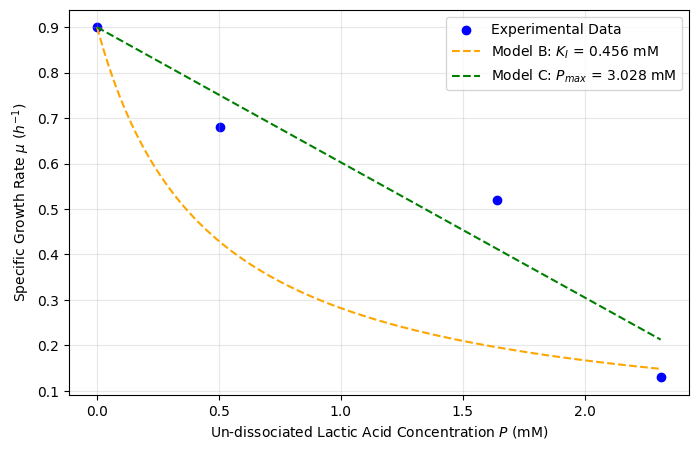

In [15]:
# Define x and y for the regression
x_c = P_mM
y_c = mu_exp / mu_P0

# Linear fit (y = mx + b)
coeffs_c = np.polyfit(x_c, y_c, 1)
slope_c = coeffs_c[0]

# Calculate P_max
P_max = -1 / slope_c
print(f"P_max: {P_max:.4f} mM")

# Models for comparison
mu_model_KI = mu_P0 / (1 + P_line / K_I)
mu_model_Pmax = mu_P0 * (1 - P_line / P_max)

# Plot both models
plt.figure(figsize=(8, 5))
plt.scatter(P_mM, mu_exp, color="blue", label="Experimental Data")
plt.plot(P_line, mu_model_KI, "--", color="orange", label=f"Model B: $K_I$ = {K_I:.3f} mM")
plt.plot(P_line, mu_model_Pmax, "--", color="green", label=f"Model C: $P_{{max}}$ = {P_max:.3f} mM")
plt.xlabel(r"Un-dissociated Lactic Acid Concentration $P$ (mM)")
plt.ylabel(r"Specific Growth Rate $\mu$ ($h^{-1}$)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Quantitative comparison using SSE:

In [16]:
# SSE for both models (evaluate at experimental P points)
mu_model_KI_exp = mu_P0 / (1 + P_mM / K_I)
mu_model_Pmax_exp = mu_P0 * (1 - P_mM / P_max)

sse_b = np.sum((mu_exp - mu_model_KI_exp) ** 2)
sse_c = np.sum((mu_exp - mu_model_Pmax_exp) ** 2)

print(f"SSE for Model B : {sse_b:.4f}")
print(f"SSE for Model C : {sse_c:.4f}")

SSE for Model B : 0.1691
SSE for Model C : 0.0233


In [17]:
# We can also check that the intercept of model C is close to 1 as expected
intercept_c = coeffs_c[1]
print(f"Intercept for Model C: {intercept_c:.4f}")

Intercept for Model C: 0.9874


We see both visually and quantitatively that the model C is better.

# Part D


Using the best model (Model C), we now express $\mu$ as a function of pH for fixed total lactate concentrations. The un-dissociated acid concentration $P$ depends on pH via the Henderson-Hasselbalch relation derived in part a):

$$P(pH) = \frac{[Total]}{1 + 10^{(pH - pK_a)}}$$

Substituting into Model C:

$$\mu(pH) = \mu_{max}\left(1 - \frac{P(pH)}{P_{max}}\right)$$

Growth stops when $\mu = 0$, i.e. when $P(pH) = P_{max}$. Solving for pH:

$$pH_{stop} = pK_a + \log_{10}\left(\frac{[Total]}{P_{max}} - 1\right)$$

Growth stops at pH = 4.306 for 1.0 g/L total lactate
Growth stops at pH = 5.432 for 10.0 g/L total lactate


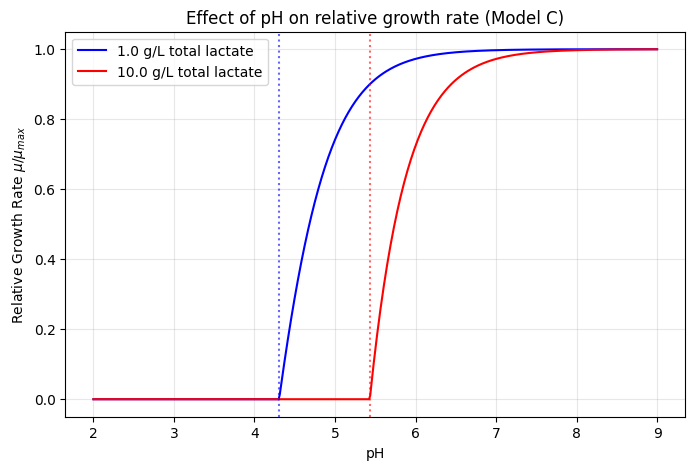

In [ ]:
# pH range to scan
pH_range = np.linspace(2.0, 9.0, 500)

def P_undiss(p_tot_gL, pH_array):
    """Un-dissociated lactic acid concentration (mM) at a given pH"""
    total_mM_ = (p_tot_gL / M_w) * 1000
    return total_mM_ / (1 + 10**(pH_array - pKa))

def mu_pH(p_tot_gL, pH_array):
    """Specific growth rate from Model C as a function of pH."""
    P = P_undiss(p_tot_gL, pH_array)
    mu = mu_P0 * np.clip(1 - P / P_max, 0, None) # limit to non-negative growth rates
    return mu

# Compute mu(pH) for both total lactate concentrations
p_tot_1, p_tot_10 = 1.0, 10.0
mu_vals_1 = mu_pH(p_tot_1, pH_range)
mu_vals_10 = mu_pH(p_tot_10, pH_range)

# pH at which growth stops is at P(pH) = P_max  =>  pH_stop = pKa + log10([Total]/P_max - 1)
pH_stop_1 = pKa + np.log10((p_tot_1 / M_w) * 1000 / P_max - 1)
pH_stop_10 = pKa + np.log10((p_tot_10 / M_w) * 1000 / P_max - 1)
print(f"Growth stops at pH = {pH_stop_1:.3f} for {p_tot_1} g/L total lactate")
print(f"Growth stops at pH = {pH_stop_10:.3f} for {p_tot_10} g/L total lactate")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(pH_range, mu_vals_1 / mu_P0, color="blue", label=f"{p_tot_1} g/L total lactate")
plt.plot(pH_range, mu_vals_10 / mu_P0, color="red", label=f"{p_tot_10} g/L total lactate")
plt.axvline(pH_stop_1, color="blue", linestyle=":", alpha=0.6)
plt.axvline(pH_stop_10, color="red", linestyle=":", alpha=0.6)
plt.xlabel("pH")
plt.ylabel(r"Relative Growth Rate $\mu / \mu_{max}$")
plt.title("Effect of pH on relative growth rate (Model C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()